In [1]:
# ✅ 1. 설치 및 라이브러리 임포트
! pip install transformers
! pip install nltk
! pip install wordcloud
! pip install matplotlib

import pandas as pd
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from transformers import pipeline
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# nltk 리소스 다운로드
#nltk.download('punkt', download_dir="D:/기계학습 전처리/nltk_data")
#nltk.download('stopwords', download_dir="D:/기계학습 전처리/nltk_data")


In [3]:
# ✅ 2. 라이브러리 import
import pandas as pd
from transformers import pipeline
from google.colab import files

# ✅ 3. 파일 업로드 및 데이터 확인
uploaded = files.upload()  # bbc_preproces.csv 업로드

df = pd.read_csv("bbc_preproces.csv",encoding='ISO-8859-1')
df = df.dropna(subset=['Content']).reset_index(drop=True)
print("✅ 데이터 로드 완료:", df.shape)
df.head()

Saving bbc_preproces.csv to bbc_preproces.csv
✅ 데이터 로드 완료: (32, 8)


,Date,Title,Url,Content,Google_noti,Xml_url,Content_len,Content_tokens
0,"March 24, 2025 at 09:50AM",BBC Press Office needs to clarify Blue Peter s...,https://cleanfeed.thetvroom.com/22559/opinion/...,A textbook example is unfolding of a self-infl...,Google ¾Ë¸®¹Ì - bbc,https://www.google.com/alerts/feeds/0409998130...,74,"['textbook', 'example', 'unfolding', 'self-inf..."
1,"March 24, 2025 at 10:38AM",BBC Radio 1 legend Andy Peebles dies as collea...,https://www.nottinghampost.com/news/celebs-tv/...,The DJ and presenter has died at the age of 76...,Google ¾Ë¸®¹Ì - bbc,https://www.google.com/alerts/feeds/0409998130...,151,"['dj', 'presenter', 'died', 'age', '76,', 'fri..."
2,"March 24, 2025 at 11:21AM",BBC in grovelling Scotland vs Greece apology o...,https://www.dailyrecord.co.uk/sport/football/f...,The Tartan Army tuning in for the first Hampde...,Google ¾Ë¸®¹Ì - bbc,https://www.google.com/alerts/feeds/0409998130...,121,"['tartan', 'army', 'tuning', 'first', 'hampden..."
3,"March 24, 2025 at 11:26AM",BBC reveal real reason stars haven't worked to...,https://www.express.co.uk/showbiz/tv-radio/203...,"BBC Today stars Nick Robinson, 61, and Emma Ba...",Google ¾Ë¸®¹Ì - bbc,https://www.google.com/alerts/feeds/0409998130...,138,"['bbc', 'today', 'stars', 'nick', 'robinson,',..."
4,"March 24, 2025 at 12:47PM",Wynne Evans 'axed' from GoCompare ads amid BBC...,https://www.gbnews.com/celebrity/wynne-evans-g...,... BBC Strictly star&39;s &39;misconduct&39; ...,Google ¾Ë¸®¹Ì - bbc,https://www.google.com/alerts/feeds/0409998130...,173,"['...', 'bbc', 'strictly', 'star&39;s', '&39;m..."


In [4]:
# ✅ 4. 감정 분석 (DistilBERT fine-tuned on SST-2)
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment(text):
    try:
        result = sentiment_model(text[:512])[0]
        return result['label']
    except:
        return 'UNKNOWN'

df['sentiment'] = df['Content'].apply(get_sentiment)
df[['Content', 'sentiment']].head()


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0
You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,Content,sentiment
0,A textbook example is unfolding of a self-infl...,NEGATIVE
1,The DJ and presenter has died at the age of 76...,POSITIVE
2,The Tartan Army tuning in for the first Hampde...,NEGATIVE
3,"BBC Today stars Nick Robinson, 61, and Emma Ba...",NEGATIVE
4,... BBC Strictly star&39;s &39;misconduct&39; ...,POSITIVE


In [23]:
# ✅ 5. 뉴스 요약 (facebook/bart-large-cnn)
#summarizer = pipeline("summarization", model="google/pegasus-cnn_dailymail")
summarizer = pipeline("summarization", model="t5-small")

def summarize_bart(text):
    if len(text.split()) < 30:
        return text  # 너무 짧은 문장은 그대로 사용
    try:
        summary = summarizer(text, max_length=60, min_length=15, do_sample=False)[0]['summary_text']
        return summary
    except:
        return '[Summary Error]'

df['summary'] = df['Content'].apply(summarize_bart)
df[['Content', 'summary']].head()


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/242M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

Device set to use cuda:0


,Content,summary
0,A textbook example is unfolding of a self-infl...,A textbook example is unfolding of a self-infl...
1,The DJ and presenter has died at the age of 76...,The DJ and presenter has died at the age of 76...
2,The Tartan Army tuning in for the first Hampde...,The Tartan Army tuning in for the first Hampde...
3,"BBC Today stars Nick Robinson, 61, and Emma Ba...","BBC Today stars Nick Robinson, 61, and Emma Ba..."
4,... BBC Strictly star&39;s &39;misconduct&39; ...,... BBC Strictly star&39;s &39;misconduct&39; ...


In [24]:
# ✅ 6. 결과 저장 및 다운로드
df.to_csv("bbc_with_summary_sentiment.csv", index=False)
files.download("bbc_with_summary_sentiment.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
# 감정 분석 모델: DistilBERT
from transformers import pipeline

sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

def get_sentiment_with_score(text):
    try:
        result = sentiment_model(text[:512])[0]
        return pd.Series([result['label'], result['score']])
    except:
        return pd.Series(['UNKNOWN', 0.0])

df[['sentiment', 'sentiment_score']] = df['Content'].apply(get_sentiment_with_score)
df[['Content', 'sentiment', 'sentiment_score']].head()


Device set to use cuda:0


,Content,sentiment,sentiment_score
0,A textbook example is unfolding of a self-infl...,NEGATIVE,0.997218
1,The DJ and presenter has died at the age of 76...,POSITIVE,0.738778
2,The Tartan Army tuning in for the first Hampde...,NEGATIVE,0.999674
3,"BBC Today stars Nick Robinson, 61, and Emma Ba...",NEGATIVE,0.987532
4,... BBC Strictly star&39;s &39;misconduct&39; ...,POSITIVE,0.841586


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128478 (\N{ROLLED-UP NEWSPAPER}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


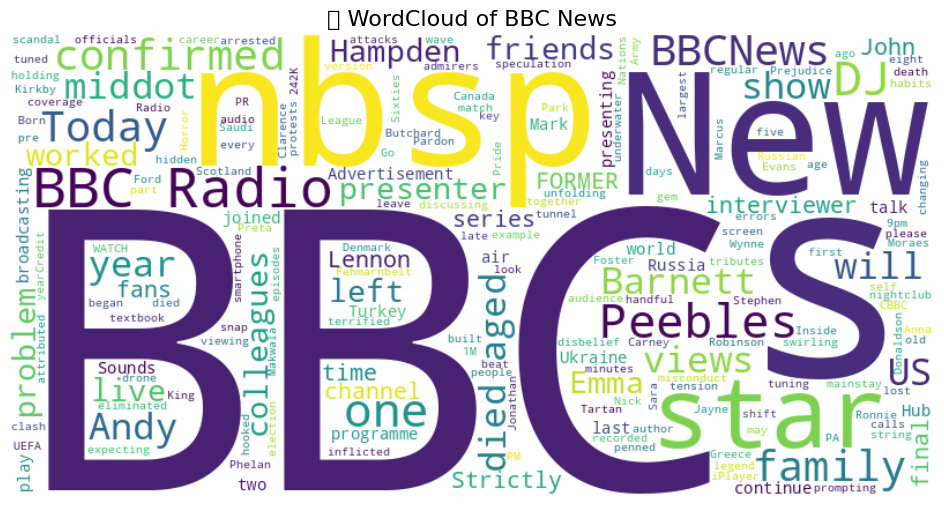

In [26]:
# WordCloud 설치 (최초 1회)
!pip install wordcloud

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 전체 텍스트 연결
text_for_wordcloud = ' '.join(df['Content'].astype(str).tolist())

# WordCloud 생성
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_for_wordcloud)

# 시각화
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("🗞 WordCloud of BBC News", fontsize=16)
plt.show()


## 요약 비교

In [39]:
import pandas as pd

# 전처리된 요약 결과 파일 로드
df = pd.read_csv("/content/bbc_with_summary_sentiment (2).csv")

# 랜덤하게 5개 샘플 출력
sample_df = df.sample(5, random_state=42)

for i, row in sample_df.iterrows():
    print(f"\n📰 원문 #{i}:\n{row['Content']}\n")
    print(f"📝 요약 결과:\n{row['summary']}\n")
    print("="*80)



📰 원문 #29:
A BBC star has warned of the dangers of drunk cycling after he was rushed to hospital following a nasty fall. Steve Stamp, who stars in the hit&nbsp;...

📝 요약 결과:
A BBC star has warned of the dangers of drunk cycling after he was rushed to hospital following a nasty fall. Steve Stamp, who stars in the hit&nbsp;...


📰 원문 #15:
... bbc.com/news Ukraine Russia BBCNews. ... US-Russia officials holding Ukraine talks in Saudi, as Russian drone attacks continue | BBC News.

📝 요약 결과:
... bbc.com/news Ukraine Russia BBCNews. ... US-Russia officials holding Ukraine talks in Saudi, as Russian drone attacks continue | BBC News.


📰 원문 #24:
BBC&39;s &39;Smoggie Queens&39; has been renewed for Series 2 - Hat Trick&39;s show stars Phil Dunning, Michelle Visage, Charlotte Riley and Mark Benton.

📝 요약 결과:
BBC&39;s &39;Smoggie Queens&39; has been renewed for Series 2 - Hat Trick&39;s show stars Phil Dunning, Michelle Visage, Charlotte Riley and Mark Benton.


📰 원문 #17:
... bbc.com/news Denmar

In [40]:
df['is_summary_same'] = df['Content'].str.strip() == df['summary'].str.strip()
print("원문과 요약이 완전히 동일한 경우 수:", df['is_summary_same'].sum())
#동일한 경우 요악이 필요 없을 가능성 또ㅡ 요약 조거을 만족 못할 data일 가능성 있음


원문과 요약이 완전히 동일한 경우 수: 30


In [41]:
df['content_len'] = df['Content'].apply(lambda x: len(str(x).split()))
df['summary_len'] = df['summary'].apply(lambda x: len(str(x).split()))
df[['content_len', 'summary_len']].describe()


,content_len,summary_len
count,32.000000,32.000000
mean,22.531250,21.125000
std,4.493611,5.398626
min,11.000000,7.000000
25%,20.750000,20.000000
50%,23.000000,22.500000
75%,25.000000,25.000000
max,30.000000,29.000000


## 감정분석 비교

In [46]:
from transformers import pipeline

# 영어 감정 분석 모델
sentiment_model = pipeline("sentiment-analysis", model="distilbert-base-uncased-finetuned-sst-2-english")

# 감정 및 점수 분리 추출
def get_sentiment_and_score(text):
    result = sentiment_model(str(text)[:512])[0]
    return pd.Series([result['label'], result['score']])

df[['sentiment', 'sentiment_score']] = df['Content'].apply(get_sentiment_and_score)
df.to_csv("/content/bbc_with_summary_sentiment (2).csv", index=False,encoding='ISO-8859-1')


Device set to use cuda:0


In [49]:
# 1.감정 예측 샘플 확인
df = pd.read_csv("/content/bbc_with_summary_sentiment (2).csv",encoding='ISO-8859-1')

# 5개 샘플 확인
for i, row in df.iterrows():
    print(f"\n📰 기사 #{i}:\n{row['Content']}")
    print(f"💬 예측 감정: {row['sentiment']} (신뢰도: {row['sentiment_score']:.2f})")
    print("="*80)



📰 기사 #0:
A textbook example is unfolding of a self-inflicted PR problem at the BBC.
💬 예측 감정: NEGATIVE (신뢰도: 1.00)

📰 기사 #1:
The DJ and presenter has died at the age of 76, his friends and colleagues have confirmed. The star was a mainstay on BBC Radio 1 from 1978 to&nbsp;...
💬 예측 감정: POSITIVE (신뢰도: 0.74)

📰 기사 #2:
The Tartan Army tuning in for the first Hampden match live on the BBC were left in disbelief by a string of audio errors.
💬 예측 감정: NEGATIVE (신뢰도: 1.00)

📰 기사 #3:
BBC Today stars Nick Robinson, 61, and Emma Barnett, 40, have only worked together a handful of times with speculation swirling as to why.
💬 예측 감정: NEGATIVE (신뢰도: 0.99)

📰 기사 #4:
... BBC Strictly star&39;s &39;misconduct&39; scandal. ¡¿. WATCH HERE: Wynne Evans discussing his time on Strictly after being eliminated. BBC. Marcus Donaldson. By&nbsp;...
💬 예측 감정: POSITIVE (신뢰도: 0.84)

📰 기사 #5:
The 65-year-old plays Ronnie Phelan in the eight part series, which has has been penned by Kirkby&39;s Stephen Butchard and airs

In [50]:
# 감정 점수 분포 확인
df['sentiment_score'].describe()


,sentiment_score
count,32.000000
mean,0.936401
std,0.098239
min,0.559837
25%,0.940545
50%,0.979917
75%,0.991955
max,0.999774


<ipython-input-52-acaa8d789b1b>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='sentiment', data=df, palette='pastel')
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


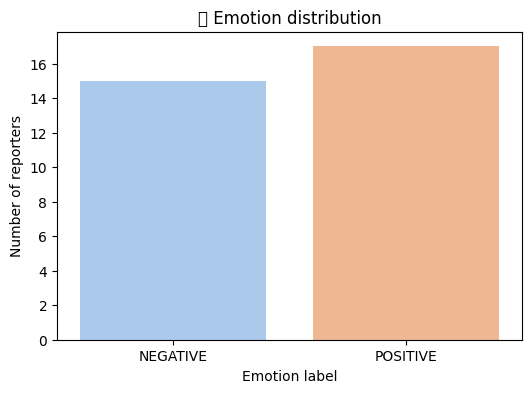

In [52]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
sns.countplot(x='sentiment', data=df, palette='pastel')
plt.title("📊 Emotion distribution")
plt.xlabel("Emotion label")
plt.ylabel("Number of reporters")
plt.show()
